---
authors:
  - name: Ricardo Barros
    url: https://ricardovobarros.github.io/
  - sschwindt
---

```{admonition} Contributor
:class: tip
This chapter was written and developed by [Ricardo Barros](https://ricardovobarros.github.io/) <img src="../img/authors/ricardo.jpg" alt="Ricardo Barros" width="50" height="50">
```


# Support Vector Machines (SVM)

Dieses Tutorial verfügt über die Support Vector Machine (SVM) Technik zur Klassifizierung von Flussbettmorphologietypen in Abhängigkeit von hydraulischen und sedimentären Transportdaten. Dieses Notebook stellt eine erweiterte Python-Übung für eine überwachte Lernanwendung mit einem nichtlinearen Modell dar.

```{admonition} Goals
+ Vorbereiten Sie einen Datensatz mit hydrodynamischen Messungen und fünf Flussbettmorphologieklassen gemäß {cite:t}`montgomery_channel-reach_1997`.
+ Verwenden Sie den Varianz-Inflationsfaktor (VIF), um Multikollinearität unter Features zu bewerten.
+ Trainieren und testen Sie ein Support Vector Machine (SVM) Modell zur Klassifizierung von Flussbettmorphologie mit einem Radial Basis Function (RBF) Kernel.
```

```{admonition} Requirements
:class: attention

Lesen und verstehen Sie die Datenverarbeitung mit {ref}`numpy`, {ref}`pandas`,{ref}`matplotlib` und {ref}`functions <chpt-functions>`. Wir gehen davon aus, dass Sie mit grundlegenden statistischen Parametern vertraut sind, wie z.B. Gaußsche Wahrscheinlichkeitsverteilungen, deren Mittelwert und deren Standardabweichungswerte.
```

Enable interactive reading and executing code blocks with [![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/hydro-informatics/jupyter-python-course/main) and find *morphology-predictor-svm.ipynb*. Alternatively, install {ref}`Python <install-python>` and {ref}`JupyterLab <jupyter>` locally and **[download](https://github.com/ricardovobarros/hydro-informatics/tree/main/morphology_predictor)** this Jupyter notebook.

## Theorie

Im Bereich der Restaurierungswissenschaft bietet die Identifizierung der Flussmorphologie wesentliche Erkenntnisse, um gezielte Terraforming zu führen, die darauf abzielen, einen naturnahen Zustand einer fluvialen Landschaft wiederzuerkennen. Darüber hinaus können morphologische Muster als Prädiktoren für die Schätzung von fluvial{term}`Sedimenttransport <Sediment transport>` und umgekehrt dienen. So besteht eine bidirektionale Beziehung zwischen fluvialen Hydraulik, Sedimenttransport und morphologischen Mustern, die physischen Lebensraum für Wasserarten darstellen und sogar die Energieerzeugung {cite:p}`recking2016quantifying` beeinflussen können.

Dennoch ist die Klassifizierung und Vorhersage der flouvialen Morphodynamik aufgrund der Komplexität der Flussökosysteme und jeder Fluss eine einzigartige Umgebung. Es gibt jedoch wiederkehrende morphologische Einheiten von Flüssen mit ähnlichen Eigenschaften. Ein grundlegender Satz von repetitiven morphologischen Merkmalen wurde von {cite:t}`montgomery_channel-reach_1997` eingeführt, und wir werden uns in diesem Tutorial auf die folgenden fünf morphologischen Einheiten konzentrieren (klicken Sie auf die Artikel, um mehr zu lesen):

+ **{term}`Step pool`**
+ **{term}`Plane bed`**
+ **{term}`Furt - Kolk <Riffle pool>`**
+ **{term}`Geflecht- <Braiding>`**
+ **{term}`Sand bed`**

Roughly, these morphological units follow the above-listed order along a river with decreasing channel slope, from the steep headwaters toward the estuary, though local controls (e.g., sediment supply, confinement, or tributaries) may interrupt this sequence. Thus, *step pool* units can typically be found in steep upstream (mountain) river sections, while *sand beds* predominantly occur in low-gradient lowland river sections, close to estuaries or confluences. Note that there are many other morphological units besides, such as slackwater, swales, or bars {cite:p}`wyrick_geospatial_2014`. {numref}`Figure %s <fig-bed-morphology>` illustrates some morphological units of near-natural rivers.

```{figure} ../img/nature/morphology-overview.jpg
:alt: riverbed morphologies
:name: fig-bed-morphology


a) Ein kolluvialer Quellwasserstrom (Furtschaglbach, Österreich), b ein Kaskadenstrom (Torrent des Favrands, Frankreich), c ein Grundwasserstrom (Anse St-Jean, Québec, Kanada), d ein Stufenbeckenstrom (Dessoubre, Frankreich), e ein Planbettstrom (Dranse, Schweiz), f ein Rifflebeckenstrom (Le diable, Québec, Kanada), g ein Zopfstrom (Jenbach, Deutschland). Quelle: {cite:t}`schwindt_hydro-morphological_2017`
```

To guide restoration actions, experts often visually classify morphological units on-site, though some of them may also be distinguishable on aerial imagery. On-site (*in-situ*) expert assessments may also serve as ground truth for machine learning models. In this exercise, we will use hydrodynamic parameters with expert-based ground truth from the database [https://bedloadweb.com](https://en.bedloadweb.com/). Thus, at the end of this tutorial, you may be able to reduce the necessary amount of fieldwork, just by using hydraulic parameters that can sometimes also be retrieved from gauging stations. To this end, we will train and test an SVM model that classifies morphological units as a function of data that can be collected *in-situ* or derived from aerial imagery.

# Vorverarbeitung

## Lastdaten

We downloaded a dataset from [https://bedloadweb.com](https://en.bedloadweb.com/) ([download the *bedload_dataset*](https://raw.githubusercontent.com/hydro-informatics/jupyter-python-course/main/data/bedload_dataset) sample):

+ Die Proben stammen aus Querschnitten von 146 verschiedenen Flüssen rund um den Globus.
+ Der Datensatz umfasst Hydraulik- und Sedimenttransportparameter (z.B. Korngrößen), obwohl wir in diesem Tutorial nur die folgenden Parameter verwenden, um das SVM-Modell zu trainieren:
    + **W**: Kanalbreite (m)
    + **S*: Kanalschräge (m/m)
    + **Q**: Entlastung (m$^3$s$^{-1}$)
    + **U**: Massenstromgeschwindigkeit (m s$^{-1}$)
    + **H**: Wassertiefe (m)

In a machine learning context, **these parameters** for predicting morphological units **are also called features**. The first step is to load (and view) the data as a `pandas.DataFrame`:

In [1]:
import pandas as pd

data = pd.read_csv("data/bedload_dataset")
data

,W,S,Q,U,H,Morphology
0,65.23,0.004100,319.98,2.90,1.69,Riffle-pool
1,3.30,0.018000,1.08,1.00,0.32,Riffle-pool
2,7.00,0.001500,3.96,0.73,0.78,Riffle-pool
3,166.12,0.000680,1124.18,1.78,3.81,Riffle-pool
4,8.38,0.013018,2.50,0.83,0.38,Riffle-pool
...,...,...,...,...,...,...
1062,102.00,0.000960,171.00,1.40,1.20,Braiding
1063,8.40,0.025000,3.34,1.20,0.33,Braiding
1064,101.00,0.000440,260.00,1.50,1.80,Braiding
1065,7.50,0.025000,2.15,0.96,0.30,Braiding


## Reinigen Sie den Dataset

Um zu vermeiden, dass das SVM-Modell durch Statistiken auf Basis von Unsinneinträgen (z.B. Not-a-Number **NaN**-Werten) oder extremen Ausreißern, z.B. aus Typos, beeinflusst wird, wenden wir einige Reinigungsmethoden an.

### NaN-Werte entfernen

Der erste Reinigungsschritt besteht darin, *NaN*s zu entfernen, die später das SVM-Modell zu schlechten Schlussfolgerungen führen können.

In [2]:
# dataset essential info
data.info()
print()

# remove rows that contain at least one NaN value
data.dropna(inplace=True)

# verify that all NaN values were removed
for column in data.columns.to_list():
    print(column, ":", data[column].isnull().any())

# verify final shape of the dataset
print(data.shape)

<class 'pandas.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   W           1067 non-null   float64
 1   S           1067 non-null   float64
 2   Q           1067 non-null   float64
 3   U           1067 non-null   float64
 4   H           1067 non-null   float64
 5   Morphology  1067 non-null   str    
dtypes: float64(5), str(1)
memory usage: 59.7 KB

W : False
S : False
Q : False
U : False
H : False
Morphology : False
(1067, 6)


### Suchausreißer

Ausreißer können in extremen Umgebungen oder unter extremen Bedingungen auftreten (z.B. intensive Ausfällung), aber einige von ihnen stammen auch aus Geräteausfällen, die die Leistung des SVM-Modells beeinflussen. Das Erkennen und Entfernen solcher gerätebezogenen Ausreißer ist somit ein wesentlicher Schritt.

Die Visualisierung der Funktionen in Scatter-Plots kann hilfreich sein, um outlier Kandidaten zu erkennen. Der folgende Code-Block erstellt ein Scatter-Plot jeder Funktion und markiert seinen Mittelwert (horizontal line) und den Bereich von $\pm$2 Standardabweichungen um sie herum (vertikale Linie, vorausgesetzt eine Gaussian-ähnliche Verteilung).

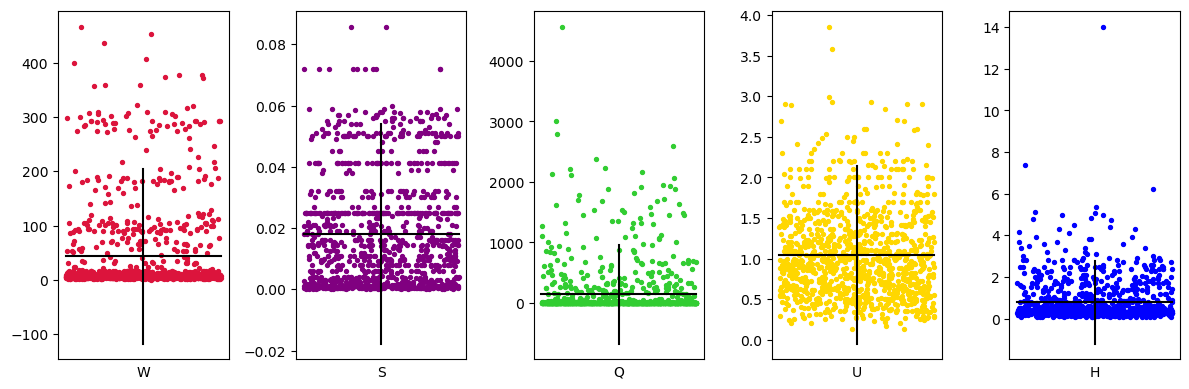

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# plot visualization parameters
labels = data.columns[0:5].tolist()
colors = ["crimson", "purple", "limegreen", "gold", "blue"]
width = 0.5
rng = np.random.default_rng(42)  # seed for a reproducible horizontal jitter

# one subplot per feature because the features have different units and magnitudes
fig, axes = plt.subplots(1, len(labels), figsize=(12, 4))
for ax, label, color in zip(axes, labels, colors):
    x = rng.random(data.shape[0]) * width - width / 2.
    ax.scatter(x, data[label], color=color, s=8)
    mean = data[label].mean()
    std = data[label].std()
    ax.plot([-width / 2., width / 2.], [mean, mean], color="k")
    ax.plot([0, 0], [mean - 2 * std, mean + 2 * std], color="k")
    ax.set_xticks([])
    ax.set_xlabel(label)

fig.tight_layout()
plt.show()

### Ausreißer entfernen

Ausreißer können mit zwei verschiedenen Methoden entfernt werden:

1. Handbuch (d. h. Expertenurteil): Identifizieren Sie Ausreißer der Merkmale und entfernen Sie sie, indem Sie Grenzen ihres Intervalls festlegen.
2. Automatisiert: Nehmen Sie eine Wahrscheinlichkeitsverteilung an und setzen Sie Limits basierend auf einer niedrigen Wahrscheinlichkeit des Auftretens.

```{admonition} Warning
:class: warning

Die automatisierte Methode ist anfälliger für das Löschen von realen, extremen Beobachtungen. Achten Sie also in der Praxis!
```

Der folgende Codeblock implementiert diese beiden (manual-expert und automatisierten) Methoden. Die manuelle Ausreißerentfernung ist  hard-coded , da die Grenzen von Experten gegeben werden sollten.

Der automatisierte Ansatz (unter der `else`-Anweisung) geht davon aus, dass die Daten einer [Gaussischen Distribution](https://en.wikipedia.org/wiki/Normal_distribution) folgen und Datenpunkte mit einem so genannten [z-score](https://en.wikipedia.org/wiki/Standard_score)4@@@ von mehr als 4 (four) in absoluten Begriffen entfernt werden. Der z-Score drückt aus, wie viele Standardabweichungen ein Wert vom Mittelwert abweicht. Bei einer Gaussschen Verteilung liegen etwa 99,994 % aller Werte innerhalb von vier Standardabweichungen vom Mittelwert. So wird eine Probe mit einer Auftretenswahrscheinlichkeit von weniger als 0,01 % automatisch als ein Ausreißer betrachtet und aus dem Datensatz entfernt. Zu diesem Zweck nutzen wir die `zscore` Funktion der `scipy` Bibliothek.

In [4]:
from scipy.stats import zscore
# choose the method to remove outliers
# remove_method = "expert_analysis"
remove_method = "zscore"

if "expert" in remove_method:
    data = data.loc[(data["Q"] < 2000) &
                    (data["W"] < 250)]
else:
    data = data[(np.abs(zscore(data.loc[:, data.columns != "Morphology"])) < 4).all(axis=1)]

# work on an independent copy of the filtered rows (avoids chained assignment issues)
data = data.copy()
data

,W,S,Q,U,H,Morphology
0,65.23,0.004100,319.98,2.90,1.69,Riffle-pool
1,3.30,0.018000,1.08,1.00,0.32,Riffle-pool
2,7.00,0.001500,3.96,0.73,0.78,Riffle-pool
3,166.12,0.000680,1124.18,1.78,3.81,Riffle-pool
4,8.38,0.013018,2.50,0.83,0.38,Riffle-pool
...,...,...,...,...,...,...
1062,102.00,0.000960,171.00,1.40,1.20,Braiding
1063,8.40,0.025000,3.34,1.20,0.33,Braiding
1064,101.00,0.000440,260.00,1.50,1.80,Braiding
1065,7.50,0.025000,2.15,0.96,0.30,Braiding


## Klassenproportionen überprüfen

Ein maschinelles Lernmodell erfordert die Grundwahrheitsdaten, um einige Qualitätsstandards zu erfüllen. Diese beinhalten (u.a.):

+ Jedes Modell benötigt eine andere Mindestanzahl an Proben [statistische Bedeutung](https://en.wikipedia.org/wiki/Statistical_significance). Es ist keine triviale Aufgabe, die minimale Anzahl von Proben zu identifizieren, die ein vertrauenswürdiges Modell liefern. Um jedoch eine Klasse korrekt darzustellen (was auch immer das bedeutet), muss die so genannte [Frequenzverteilung](https://en.wikipedia.org/wiki/Frequency_distribution) jeder Funktion ähnlich sein wie die [population](https://www.bmj.com/about-bmj/resources-readers/publications/statistics-square-one/3-populations-and-samples)Frequenzverteilung.
+ Mehr als [30 Samples](https://math.stackexchange.com/questions/1287990/estimating-population-standard-deviation-with-sample-standard-deviation) beim Umgang mit normal verteilten Variablen ist eine gute Faustregel.]
+ Idealerweise sollten die für ein Klassifikationsproblem verwendeten Klassen durch eine ähnliche Anzahl von Proben dargestellt werden. Ein unausgeglichener Datensatz kann ein Modell erzeugen, das eine korrekte Klassifizierung der Klasse mit einer größeren Anzahl von Proben vorzieht. Dies ist eine Folge der Verwendung von Genauigkeit als Leistungsmetrik. Genauigkeit ist das Verhältnis der richtigen Vorhersagen und der Gesamtzahl der Vorhersagen ($accuracy = n_{correct\_predictions}/ n_{samples}$). Durch die Begünstigung der Gesamtzahl der korrekten Vorhersagen über eine ausgeglichene, maskiert die Genauigkeit die Bedeutung der korrekten Vorhersage der unterrepräsentierten Klassen. Daher sind klassenempfindliche Metriken, wie [Präzision und Rückruf](https://en.wikipedia.org/wiki/Precision_and_recall), zur Messung der Leistung von auf unsymmetrische Daten geschulten Modellen bevorzugt.
+ Lösungen für den Ausgleich unausgeglichener Proben umfassen:
    + Sammeln neuer Daten oder Erzeugen von synthetischen Daten (z.B. durch Überprägen der unterrepräsentierten Klassen oder mit [Monte Carlo](https://en.wikipedia.org/wiki/Monte_Carlo_method)-Methoden).
    + [Weighting](https://www.kdnuggets.com/2019/11/machine-learning-what-why-how-weighting.html)-Klassen, was bedeutet, höhere Gewichte an unterrepräsentierte Klassen zuzuweisen, um ihre Bedeutung im Trainingsprozess zu erhöhen. Die Auswirkungen von Gewichten oder Entscheidungsschwellen beim Abhandeln zwischen wahren und falschen positiven Zinssätzen können mit einer [ROC-Kurve](https://en.wikipedia.org/wiki/Receiver_operating_characteristic).

In diesem Tutorial können die Proben als ausgeglichen angesehen werden, mit Ausnahme der Sandbettklasse (siehe Ausgabe unten). Gewichtung und ROC-Kurven werden hier nicht berücksichtigt. Wenn die Empfindlichkeit und Spezifität der Sandbettklasse bei der Klassifizierung von Testdaten akzeptabel waren, könnte das Modell auch für die Sandbettklassifikation verwendet werden, ohne dass die Techniken ausgleichen müssen.

In [5]:
data["Morphology"].value_counts()

Morphology
Step-pool      247
Plane Bed      243
Riffle-pool    241
Braiding       228
Sand bed        79
Name: count, dtype: int64

## Ableiten neuer Vorhersagen

Manchmal ist es möglich, aus den vorhandenen neue sinnvolle Features zu berechnen. Zum Beispiel bekannte Prädiktoren für Morphologie sind:

+ the product of (energy) slope $S$ (-), bulk flow velocity $U$ (m/s), and water depth $H$ (m), which is proportional to the specific stream power $\omega = \rho g U H S$ (W/m$^2$), where $\rho$ is the density of water and $g$ is gravitational acceleration; similarly, the product of $H$ and $S$ is proportional to the {term}`bed shear stress <Dimensionless bed shear stress>` $\tau = \rho g H S$
+ das Verhältnis der Entlastung $Q$ (m$^3$/s) und der Breite $W$ (m), das ist die Einheit Entladung $q = Q/W$ (m$^2$/s)

```{warning}
Das Ableiten neuer Merkmale aus bestehenden durch einfache Operationen kann zu einer falschen Korrelation führen, was zu unzuverlässigen Modellen führt.
```

In [6]:
# compute new columns for the new features SUH and Q/W
data["SUH"] = data["S"] * data["U"] * data["H"]
data["Q/W"] = data["Q"] / data["W"]
data

,W,S,Q,U,H,Morphology,SUH,Q/W
0,65.23,0.004100,319.98,2.90,1.69,Riffle-pool,0.020094,4.905412
1,3.30,0.018000,1.08,1.00,0.32,Riffle-pool,0.005760,0.327273
2,7.00,0.001500,3.96,0.73,0.78,Riffle-pool,0.000854,0.565714
3,166.12,0.000680,1124.18,1.78,3.81,Riffle-pool,0.004612,6.767277
4,8.38,0.013018,2.50,0.83,0.38,Riffle-pool,0.004106,0.298329
...,...,...,...,...,...,...,...,...
1062,102.00,0.000960,171.00,1.40,1.20,Braiding,0.001613,1.676471
1063,8.40,0.025000,3.34,1.20,0.33,Braiding,0.009900,0.397619
1064,101.00,0.000440,260.00,1.50,1.80,Braiding,0.001188,2.574257
1065,7.50,0.025000,2.15,0.96,0.30,Braiding,0.007200,0.286667


## Multikollinearität verifizieren

Korrelierte Merkmale (d.h. statistisch abhängige Messparameter) können zu unzuverlässigen Modellen führen. Betrachten Sie beispielsweise einen Wissenschaftler, der maschinelles Lernen (ML)-Modelle verwenden möchte, um die Anzahl der Touristen vorherzusagen, die in Brasilien während ihres Urlaubs versenkt werden. Sie will die Sonneneinstrahlungsintensität und die Anzahl der als Features verkauften Eisschaufeln verwenden. Der Wissenschaftler kann feststellen, dass beide Merkmale relevant sind, um die Anzahl der sonnenverbrannten Touristen vorherzusagen, aber der Grund für diese Feststellung ist, dass die Anzahl der verkauften Eiswürfel und die Intensität der Sonnenstrahlung korreliert. So hat der Wissenschaftler keine Möglichkeit, die reale Bedeutung jeder Funktion bei der Vorhersage von sonnenverbranten Touristen zu kennen, weil die Merkmale gleichzeitig wachsen und abnehmen. Übrigens verursacht der Eiskonsum keine Sonnenbrands (nor umgekehrt); beide werden von einer gemeinsamen Ursache (Sunshine) angetrieben, aber das ist ein weiteres Thema.

Zu diesem Zweck ist es wichtig, die Korrelation zwischen den Merkmalen zu untersuchen und die Beseitigung von korrelierten Merkmalen zu berücksichtigen, um ein zuverlässigeres Modell zu produzieren. Eine Möglichkeit, die Kollinearität visuell zu erkennen, zeigt die Kombination zweier Variablen in einem Streudiagramm. Zu diesem Zweck werden die folgenden Abbildungshilfen bei der Feststellung folgender Aspekte des `bedload_dataset`:

+ Es besteht eine starke lineare Korrelation zwischen den $H$ und $Q/W$ Features, was nicht überraschend ist, weil $Q/W = U \cdot H$.
+ Es gibt nur eine schwache lineare Korrelation zwischen $W$ und $U$ (Korrelationskoeffizient von ca. 0,37, siehe unten die Heatmap).
+ Die Strömungsgeschwindigkeit $U$ ist etwa glockenförmig (siehe Hauptdiagonale).

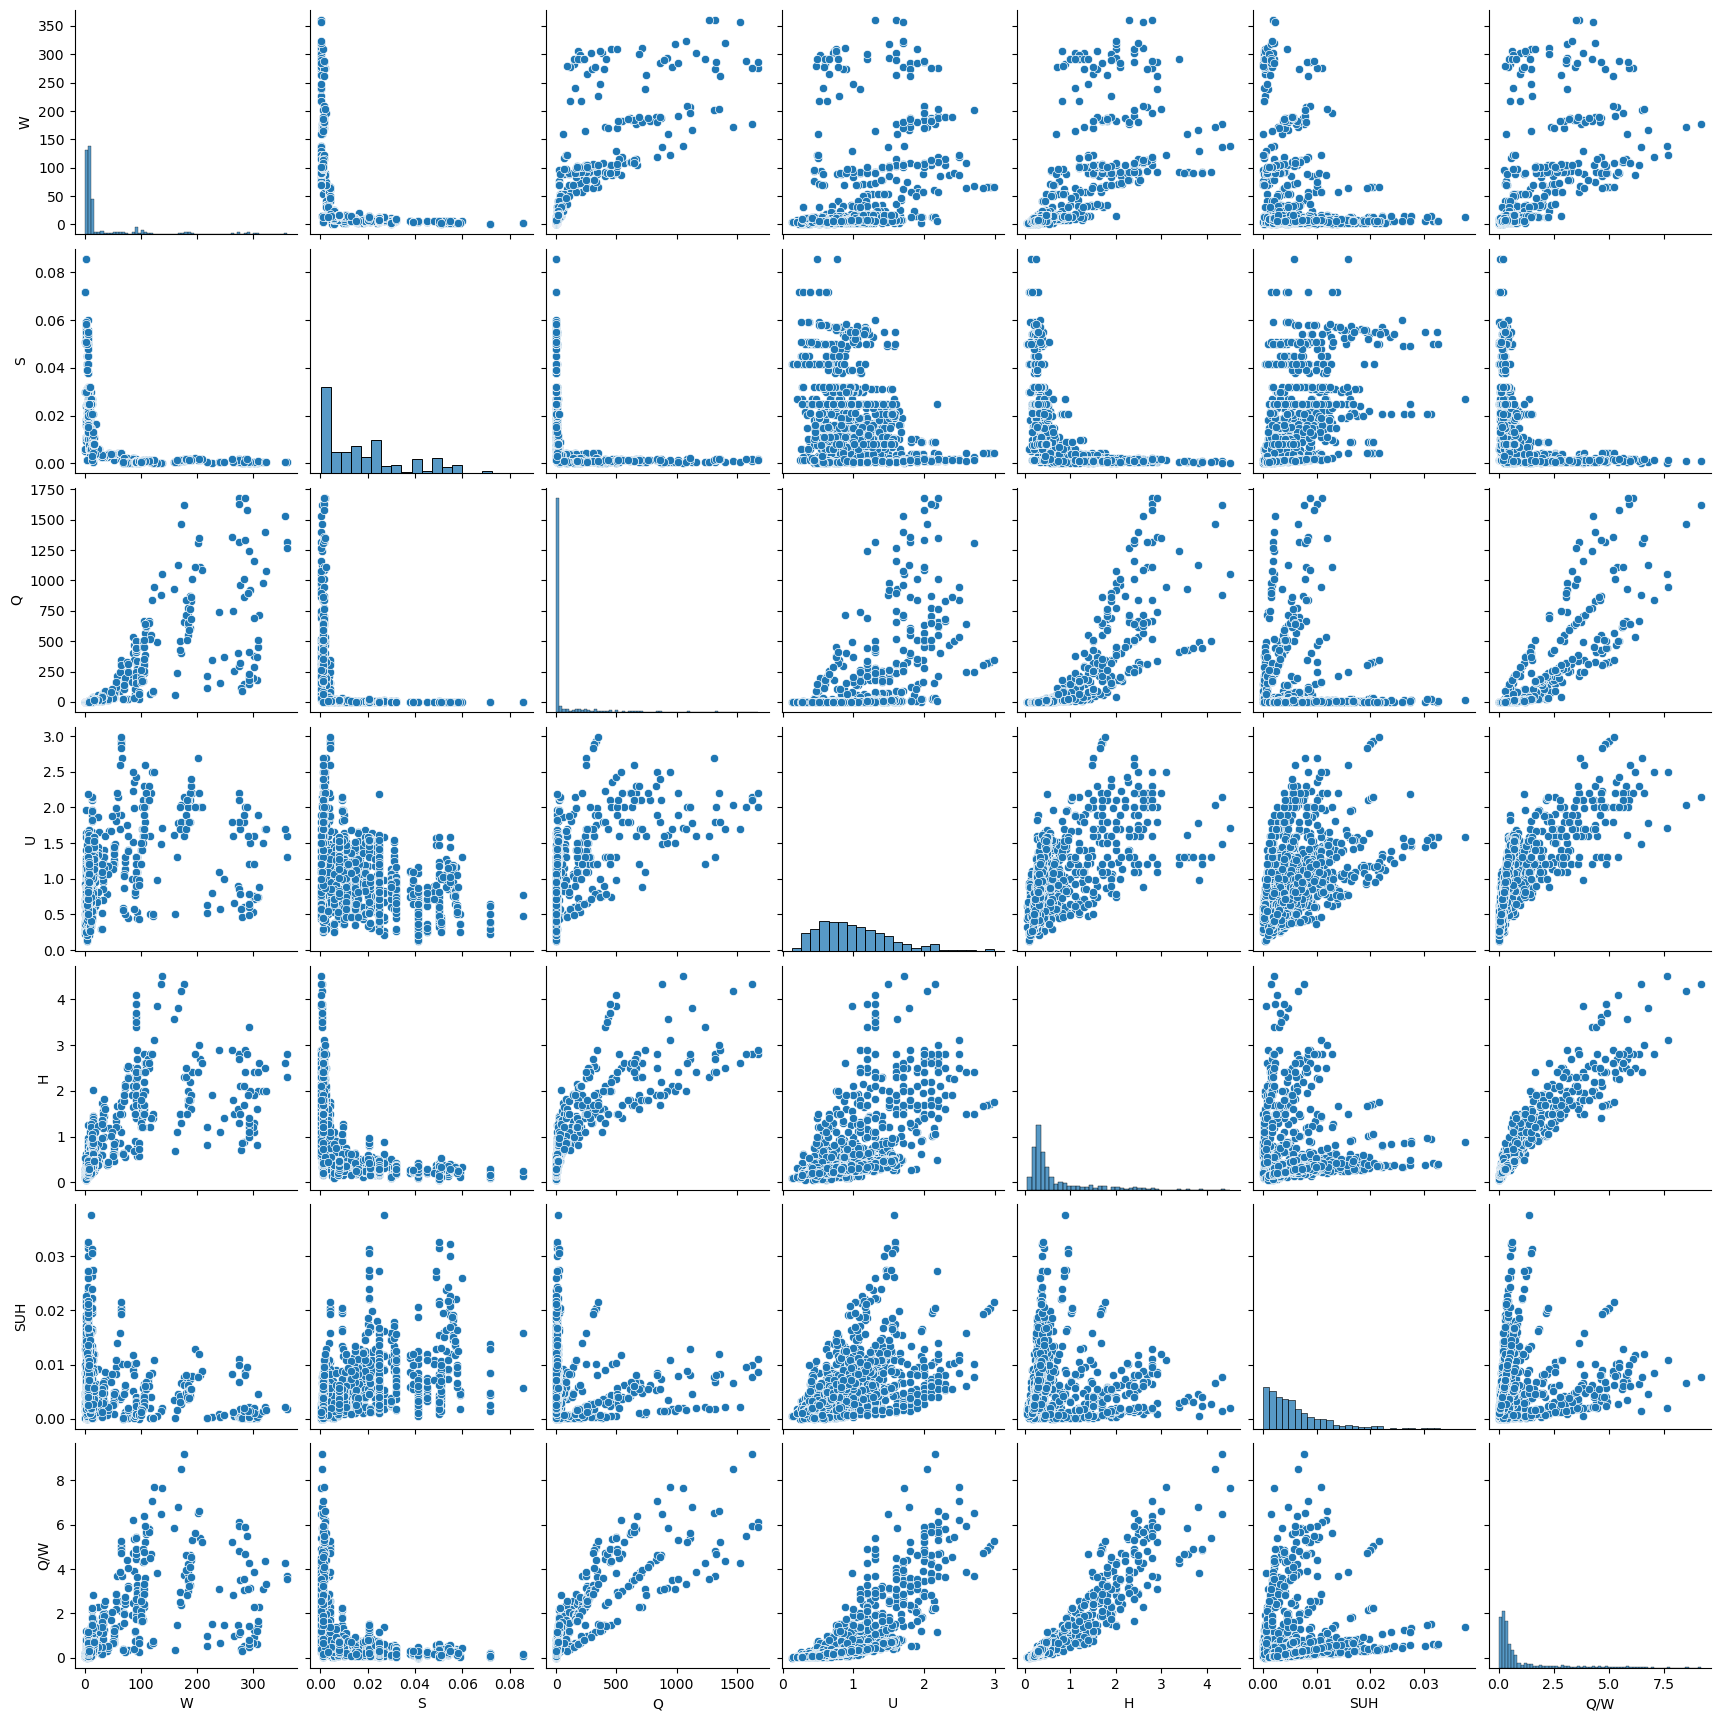

In [7]:
import seaborn as sns

# plot scatter of the 2d (two-dimensional) combination of features
sns.pairplot(data.loc[:, data.columns != "Morphology"])
plt.show()

Darüber hinaus ist eine [heatmap](https://en.wikipedia.org/wiki/Heat_map)] eine weitere effiziente Methode, um lineare Korrelationen zwischen Merkmalen zu visualisieren. Auch die Berechnung [linear correlation](https://en.wikiversity.org/wiki/Correlation) ermöglicht die quantitative Analyse.]

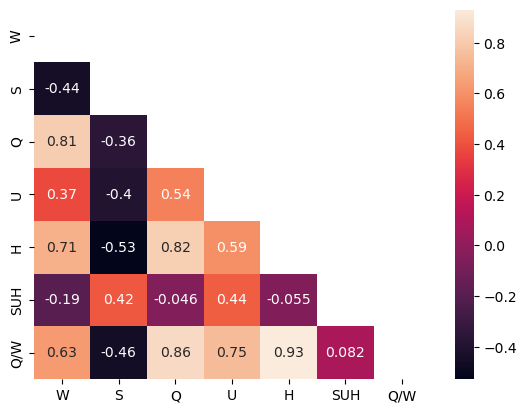

In [8]:
# verify linear correlation
feature_corr_df = data.loc[:, data.columns != "Morphology"].corr()
mask = np.zeros_like(feature_corr_df, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(feature_corr_df,
            annot=True,  # print value inside the grid
            mask=mask  # mask values (boolean matrix)
            )
plt.show()

## Varianz-Inflationsfaktor (VIF)

Eine unkomplizierte Methode zur Bewertung [multicollinearity](https://en.wikipedia.org/wiki/Multicollinearity) ist die Berechnung des Varianz-Inflationsfaktors (**VIF**) für jede Funktion, die quantifiziert, wie gut eine Funktion durch die anderen Merkmale erläutert werden kann.

Der erste Schritt zur Berechnung des VIF behandelt ein Feature als [abhängige Variable](https://www.scribbr.com/methodology/independent-and-dependent-variables/) und passt ein [lineares Regressionsmodell](https://www.youtube.com/watch?v=nk2CQITm_eo) unter Verwendung der anderen Features als [unabhängige Variablen](https://www.scribbr.com/methodology/independent-and-dependent-variables/). Zweitens speichern Sie den entsprechenden Bestimmungskoeffizienten $R^2$, der vom linearen Modell geliefert wird.

Schließlich kann die VIF für jedes Merkmal mit folgender Gleichung berechnet werden:

$$
VIF_{feature(n)} = 1/(1-R^2_{feature(n)})
$$

+ $VIF_{feature(n)}$ ist der Varianz-Inflationsfaktor der $n$-th-Funktion und
+ $R^2_{feature(n)}$ ist der Bestimmungskoeffizient, der sich aus der linearen Regression des $n$-th-Features auf allen anderen Features ergibt.


Beachten Sie, dass die größere $R^2$ (d.h. umso besser das lineare Regressionsmodell) die Inflation ist. Mit anderen Worten weisen große VIF-Werte eine hohe Korrelation des betrachteten Merkmals mit   zumindest  einer der anderen Merkmale auf. Dennoch ist es nicht möglich, nur auf der VIF basierend zu sagen, was  other feature  dazu führt, dass der VIF aufgeblasen wird.

In der Regel gibt ein VIF größer als 10 (ten) einen ungeeigneten Satz von Merkmalen an, um ein zuverlässiges ML-Modell zu erzeugen. Idealerweise sollte der VIF kleiner als 5 (fünf) bleiben, was als moderate Korrelation gilt {cite:p}`franke2010multicollinearity`. Diese Referenzwerte sind jedoch keine allgemein gültige Regel. Ein VIF gleich oder größer als 10 kann noch ein gutes Modell liefern.

Eine weitere Analyse zur Untersuchung der Auswirkungen eines hohen VIF auf korrelierte Funktionen kann durchgeführt werden, indem eine Funktion zu einer Zeit entfernt und untersucht wird, wie die Feature-Entfernung die Variation des [Standardfehler](https://en.wikipedia.org/wiki/Standard_error) und [p-value](https://en.wikipedia.org/wiki/P-value) des Modells beeinflusst.

In diesem Tutorial haben 2 Funktionen einen VIF $>$ 10 (insbesondere $H$ und $Q/W$), wie die folgenden Code-Block-Shows zeigen.

In [9]:
from sklearn.linear_model import LinearRegression

# compute VIF for the features
def calculate_vif(df, features):
    vif = {}

    for feature in features:
        # extract all the other features you will regress against
        X = [f for f in features if f != feature]
        X, y = df[X], df[feature]

        # extract r-squared from the fit
        r2 = LinearRegression().fit(X, y).score(X, y)

        # compute VIF
        vif[feature] = 1 / (1 - r2)
    # return VIF DataFrame
    return pd.DataFrame({"VIF": vif})

# call function calculate_vif with features as input
calculate_vif(df=data,
              features=data.columns[data.columns != "Morphology"].to_list())

,VIF
W,4.691707
S,2.983335
Q,9.278038
U,6.515027
H,14.721236
SUH,3.028896
Q/W,27.648327


## Features entfernen, um VIF zu reduzieren

Mit dem Ziel, die Funktion VIFs auf weniger als 5 zu reduzieren, verwenden wir in diesem Tutorial einen Test-und-Fehler-Ansatz. Die Änderung des folgenden Code-Blocks zeigt, dass die Entfernung von $H$ und $Q$ ausreicht, um die VIFs der übrigen Features auf weniger als 5 zu reduzieren. Insbesondere gehen diese beiden entfernten Variablen auch in die oben vorgestellten Features $Q/W$ und $SUH$. Obwohl $H$ und $Q$ entfernt werden, tragen sie immer noch "Informationen" zum Abschlussmodell bei.

Die Kombination von korrelierten Merkmalen, um eine neue zu produzieren und später zu entfernen, ist ein gemeinsamer Ansatz, um VIFs zu reduzieren. Da wir durch Entfernen einiger Merkmale gute VIF-Werte lieferten, ist keine weitere Analyse erforderlich.

```{admonition} Principal Component Analysis (PCA)
Alternativ ist eine [Principal Component Analysis (PCA)](https://www.youtube.com/watch?v=FgakZw6K1QQ) eine effektive Methode zur Reduzierung der Dimensionalität (dh die Anzahl der Datensatzmerkmale, die in ein Modell gelangen), um die Zuverlässigkeit eines Modells zu erhöhen und gleichzeitig den Informationsverlust zu minimieren.
```

Schließlich werden die Funktionen, die zum Trainieren und Testen des SVM-Modells verwendet werden, durch die Ausgabe des Codeblocks unten angezeigt.

In [10]:
# trial-and-error approach: remove features to get VIFs < 5
data = data.loc[:, (data.columns != "H") & (data.columns != "Q")]

# compute VIF again to verify if VIFs are less than 5
calculate_vif(df=data,
              features=data.columns[data.columns != "Morphology"].to_list())

,VIF
W,1.872494
S,2.451387
U,4.778947
SUH,2.855595
Q/W,3.628840


## Split Test- und Trainingsdatensätze
Der letzte Vorbereitungsschritt für den Aufbau des SVM-Modells besteht darin, ein Training und einen Testdatensatz aus dem gesamten `bedload_dataset` abzuleiten. Die Auswahl eines Teils der Daten zur Erstellung eines Trainings und eines Testdatensatzes ist in der Regel eine heuristische Wahl. Hier verwenden wir 30 % der Daten, um später eine endgültige Hypothese zu testen. Beachten Sie, dass innerhalb der gespaltenen Datensätze die Indizes der Proben (Reihen der tabellarischen Daten) den Indizes ihrer Klassen in den  target datasets  entsprechen.

In [11]:
from sklearn.model_selection import train_test_split


# split dataframes with features and labels only
labels = data.loc[:, "Morphology"]
predictors = data.loc[:, data.columns[data.columns != "Morphology"]]

# split testing set as 30% of the data
# X corresponds to the features (matrix form)
# y corresponds to the labels (vector form)
X_train, X_test, y_train, y_test = train_test_split(predictors,
                                                    labels,
                                                    test_size=0.3,
                                                    random_state=42  # seed for random selection of data
                                                    )

# visualize training and testing sets
print("TRAINING DATASET PREDICTORS")
print(X_train.head(), "\n")
print("dataframe size", X_train.shape, "\n")
print("------------------------------------------")
print("TRAINING DATASET TARGET")
print(y_train, "\n")
print()
print("------------------------------------------------------------------------------------\n")

print("TESTING DATASET PREDICTORS")
print(X_test.head())
print("dataframe size", X_test.shape, "\n")
print("------------------------------------------")
print("TESTING DATASET TARGET")
print(y_test.head())
print("Vector size", y_test.shape)

TRAINING DATASET PREDICTORS
          W        S     U       SUH       Q/W
256    6.91  0.01100  1.02  0.003366  0.277858
397   88.09  0.00210  1.99  0.008149  3.889545
586   14.02  0.02070  1.34  0.022190  1.078459
526  218.00  0.00041  0.52  0.000175  0.541284
9      8.00  0.02000  1.18  0.007316  0.370000 

dataframe size (726, 5) 

------------------------------------------
TRAINING DATASET TARGET
256      Plane Bed
397      Plane Bed
586      Step-pool
526       Sand bed
9      Riffle-pool
          ...     
89     Riffle-pool
337      Plane Bed
476      Plane Bed
123    Riffle-pool
876       Braiding
Name: Morphology, Length: 726, dtype: str 


------------------------------------------------------------------------------------

TESTING DATASET PREDICTORS
          W        S     U       SUH       Q/W
203    2.57  0.01040  1.58  0.008216  0.793774
937  105.00  0.00096  1.90  0.002918  3.076190
546   93.00  0.00050  1.10  0.001320  2.688172
214   53.04  0.00380  1.44  0.004596  1.

# Erstellen Sie das SVM-Modell

## Arbeitsprinzip
Eine Support Vector Machine (SVM) ist ein Lernalgorithmus, der nach einem sogenannten **hyperplane* sucht, der Funktionsklassen optimal trennt. Um eine optimale Trennung zu finden, versucht der Algorithmus, den Abstand (oder den Rand) vom Hyperplan zu den nächsten Datenpunkten zu maximieren. Die Datenpunkte, die sich an (oder innen) den Grenzen der Marge befinden, werden auch mit **Unterstützungsvektoren** bezeichnet, da sie als Referenz auf  draw  das Hyperplane arbeiten (siehe {numref}`Figure %s <svm-margin-morphology>` unten).

```{figure} ../img/datascience/svm-margin.jpg
:alt: datascience
:name: svm-margin-morphology


Illustration einer Hyperebene und Ränder einer SVM. Quelle: Ricardo Barros
```

Nehmen Sie beispielsweise an, dass zwei der obigen Klassen linear trennbar sind. Das Trenn-Hyperplane wird durch $\vec{w} \cdot \vec{x} + b = 0$ definiert und die Regionen, die jede Klasse enthalten, können als:

$\vec{w} \cdot \vec{x} + b \geq +1$ -->   Klasse Red  , und
$\vec{w} \cdot \vec{x} + b \leq -1$ -->   Klasse Blau  

wo

+ $\vec{w}$ ist der Gewichtsvektor (normal zum Hyperplan),
+ $\vec{x}$ ist der Merkmalsvektor einer Probe,
+ $b$ ist das Programm (auch **bias**) und
+ Der Wert von $1$ ist ein Skalierungskongress, da $\vec{w}$ und $b$ ohne Veränderung des Hyperplans mit jedem positiven Faktor multipliziert werden können.

Mit dieser Konvention ist die Margenbreite $2 / \lVert \vec{w} \rVert$. Somit entspricht die Maximierung des Randes (nach einigen Schritten, die hier nicht diskutiert werden) der Minimierung des folgenden Ausdrucks:

$\min \left(0.5 \, \vec{w}^T \vec{w}\right)$

wobei $\vec{w}^T$ der **übersetzte Gewichtsvektor* ist, vorbehaltlich der Beschränkung, dass alle Trainingsproben auf der richtigen Seite des Randes liegen.

In der realen Welt ist es jedoch üblich, Probleme zu finden, bei denen Klassen nicht linear trennbar sind. In solchen Situationen können sogenannte **Kernel** eingesetzt werden. Ein Kernel ist eine Funktion, die implizit die Eigenschaften $\vec{x}$ in einen Raum mit höheren Dimensionen (d.h. neue Features, die Kombinationen der verfügbaren Features sind) abbildet, wo die Klassen linear trennbar werden können. Der sogenannte *Kernel-Trick* ermöglicht dies ohne explizite Berechnung der neuen Features.

Hier wenden wir die [Radial Basis Function (RBF)](https://en.wikipedia.org/wiki/Radial_basis_function_kernel) kernel an. Der RBF ist ein beliebter Kernel, weil er implizit $\vec{x}$ in einen unendlichen Spielraum mißt, der ihn sehr flexibel macht. Diese Flexibilität bedeutet jedoch auch, dass ein RBF-SVM die Trainingsdaten überrüsten kann, wenn seine Parameter nicht sorgfältig abgestimmt werden (siehe nächste Abschnitt).

```{admonition} Get more details...
:class: hint
+ Weitere Informationen zum  SVM  Berechnungsverfahren finden Sie unter [analyticsvidhya.com](https://www.analyticsvidhya.com/blog/2021/10/support-vector-machinessvm-a-complete-guide-for-beginners/).
+ Für eine vollständige Vorlesung über  SVM  (von [MIT](https://mit.edu) bereitgestellt), besuchen Sie deren [YouTube channel](https://www.youtube.com/watch?v=_PwhiWxHK8o)].
```

## k-fache Kreuzvalidierung

SVMs mit einem RBF-Kernel können mit zwei Parametern abgestimmt werden:

1.  C  : bestimmt, wie permissiv die Margen sind. Sie unterscheidet sich zwischen einer **hard-Marge** (d.h. einer Marge, die ein Eindringen von Datenpunkten nur wenig oder gar nicht ermöglicht) und einer **soft-Marge*** (d.h. einer Marge, die das Eindringen von Datenpunkten innerhalb der Marge ermöglicht). Eine höhere   C   entspricht einer härteren Marge.
2.  gamma  : bestimmt den Bereich der Ähnlichkeit zwischen den Proben. Es ist der einzige Parameter des RBF-Kernels. Je höher Gamma ist, desto enger ist der Einfluss einer markierten Probe auf die Klassifizierung einer neuen Probe (d.h. nur sehr nahe Proben werden als ähnlich betrachtet).

Harte Margen können auch als **-Sensitivität des Hyperplans** interpretiert werden, wenn es auf die Daten passt. Je härter der Rand, desto mehr die Hyperplane verdreht, um keinen Datenpunkt in den Rand eindringen zu lassen. So erhöhen sowohl ein hohes   C  als auch ein hoher   gamma   das Risiko einer Überfüllung.

In diesem Tutorial definieren wir  C  basierend auf einem Test-und-Fehler-Ansatz und  gamma  basierend auf einem fünffachen [cross-validation](https://machinelearningmastery.com/k-fold-cross-validation/). Der folgende Codeblock baut die SVM mit der `sklearn`Bibliothek auf und gibt die Validierungs- und Trainingsfehlerkurven, die sich aus unterschiedlichen  gamma  ergeben.

```{admonition} Further reading
:class: hint
Für ein  C  und  gamma  Suchcodebeispiel werfen Sie einen Blick in das [scikit-learn docs](https://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html)].
```

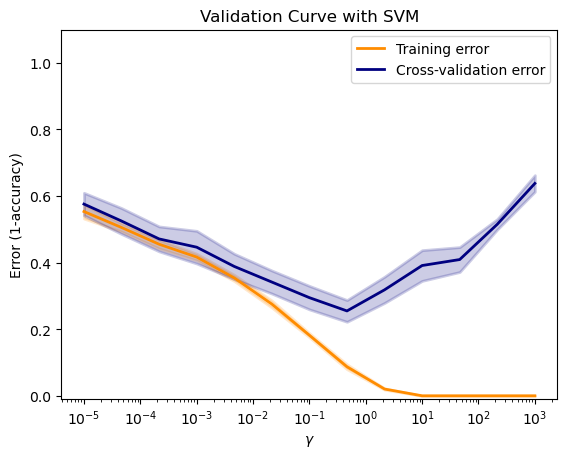

In [12]:
from sklearn.svm import SVC
from sklearn.model_selection import validation_curve


# define C, gamma range, kernel and number of cross-val. folds
param_range = np.logspace(-5, 3, 13)  # gamma values to test
C = 500  # chosen hyperparameter through tuning
kernel = "rbf"  # radial basis function
n_of_folds = 5

# perform 5-fold cross-validation and save training and validation error
train_scores, test_scores = validation_curve(SVC(kernel=kernel,
                                                 C=C),
                                             X_train,
                                             y_train,
                                             param_name="gamma",
                                             param_range=param_range,
                                             scoring="accuracy",
                                             cv=n_of_folds
                                             )

# convert accuracy into error
train_error = 1 - train_scores
validation_error = 1 - test_scores

# compute 5-fold cross-validation mean and std of error
train_error_mean = np.mean(train_error, axis=1)
train_error_std = np.std(train_error, axis=1)
validation_error_mean = np.mean(validation_error, axis=1)
validation_error_std = np.std(validation_error, axis=1)

#-------------------------------------------------------------------

# visualization of training and error validation
plt.title("Validation Curve with SVM")
plt.xlabel(r"$\gamma$")
plt.ylabel("Error (1-accuracy)")
plt.ylim(-0.01, 1.1)
lw = 2
plt.semilogx(
    param_range, train_error_mean, label="Training error", color="darkorange", lw=lw
)
plt.fill_between(
    param_range,
    train_error_mean - train_error_std,
    train_error_mean + train_error_std,
    alpha=0.2,
    color="darkorange",
    lw=lw,
)
plt.semilogx(
    param_range, validation_error_mean, label="Cross-validation error", color="navy", lw=lw
)
plt.fill_between(
    param_range,
    validation_error_mean - validation_error_std,
    validation_error_mean + validation_error_std,
    alpha=0.2,
    color="navy",
    lw=lw,
)
plt.legend(loc="best")
plt.show()

## Wählen Sie optimale Parameter

Die Entscheidung über optimale Parameter für den SVM hängt von Ihrem Urteil ab. Zur Auswahl optimaler Parameter in diesem Tutorial quantifiziert der nachfolgende Codeblock das oben gezeigte Diagramm (insbesondere die blaue Kurve) in tabellarischer Form und speichert das Gamma, das den kleinsten Fehler liefert (  gamma opt   ).

In [13]:
# save optimal gamma
index_min = int(np.argmin(validation_error_mean))
validation_error_min = validation_error_mean[index_min]
gamma_opt = param_range[index_min]  # gamma that gives minimum validation error

# visualize error evolution with gamma
columns = ["Mean validation error", "gamma"]
array = np.array([validation_error_mean, param_range]).transpose()

print(pd.DataFrame(array, columns=columns), "\n")
print("Minimum mean validation error:", validation_error_min)
print("optimal gamma:", gamma_opt)

    Mean validation error        gamma
0                0.575739     0.000010
1                0.524856     0.000046
2                0.471101     0.000215
3                0.446311     0.001000
4                0.388474     0.004642
5                0.341606     0.021544
6                0.294709     0.100000
7                0.254861     0.464159
8                0.318262     2.154435
9                0.391252    10.000000
10               0.409173    46.415888
11               0.515144   215.443469
12               0.637789  1000.000000 

Minimum mean validation error: 0.2548606518658479
optimal gamma: 0.46415888336127725


## Zugoptimale Hypothese SVM Modell

Nach der Definition eines Gammas, der den kleinsten Validierungsfehler (  gamma opt  ) liefert, können wir auf dem gesamten Trainingsdatensatz ein optimales Hypothesenmodell (  h opt   ) trainieren. Darüber hinaus können wir die Genauigkeit des Modells bewerten, indem wir es verwenden, um den Testdatensatz zu klassifizieren. Der nachfolgende Codeblock zeigt den Trainingsablauf, die Anpassung des SVM (d.h. eine optimale Hypothese) und druckt den Fehler der optimalen Hypothese am Testdatensatz.

In [14]:
# train optimal model and evaluate accuracy
h_opt = SVC(kernel=kernel,
            gamma=gamma_opt,
            C=C)  # instantiate optimal model
h_opt.fit(X_train, y_train)  # train the model with entire training set
print("Error (1-Accuracy) of h_opt on testing data: \n -->>", 1 - h_opt.score(X_test, y_test))

Error (1-Accuracy) of h_opt on testing data: 
 -->> 0.19551282051282048


## Leistungsbewertung (Konfusionsmatrix)

Schließlich erzeugt der folgende Codeblock die sogenannte **confusion matrix**, um die optimale Leistung des Hypothesenmodells bei der Klassifizierung der Proben mit unterschiedlichen Morphologien zu bewerten. Die Verwirrungsmatrix verwendet die Gesamtzahl der Proben und visualisiert ihre wahren und vorhergesagten morphologischen Einheiten.

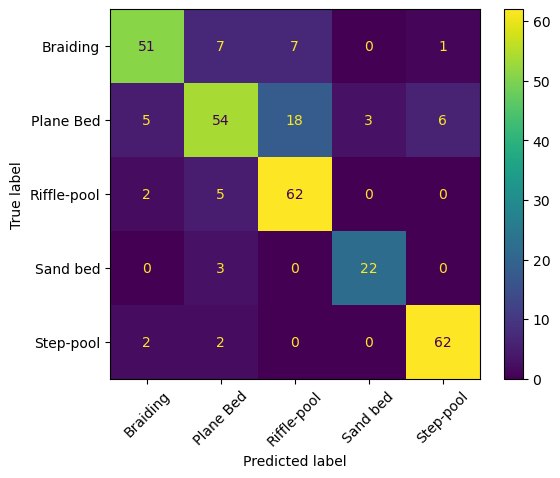

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

# plot confusion matrix
ConfusionMatrixDisplay.from_estimator(h_opt,  # trained optimal hypothesis model
                                      X_test,
                                      y_test,
                                      )
plt.xticks(rotation=45)
plt.show()

Die Verwirrungsmatrix eines exakten Modells hat nur Diagonaleinträge größer als Null, während alle anderen Null sind. Die oben gezeigte Verwirrungsmatrix zeigt, dass unser SVM-Modell bei der Vorhersage von Schritt-Pool (62 von 66 Wahrzeichen-Beobachtungen) und Riffle-Pool (62 von 69) Morphologien gut ausführt. Trotz der geringeren Anzahl von Beobachtungen prognostiziert das Modell auch die meisten Sandbettbeobachtungen korrekt (22 von 25). Diese 25 wahr-markierten Sandbett-Beobachtungen (begrenzt auf 66 Stufen oder 86 Ebenenbett-Beobachtungen) sind jedoch wenig, was die Sandbett-Statistik weniger robust macht. So sind die Sandbett-Beobachtungen unsymmetrisch, und eine Lösung zur Erhöhung der Zuverlässigkeit könnte es sein, mehr Sandbett morphologische Einheiten (wie oben erläutert).

Die schwächste Leistung betrifft Flugzeugbettmorphologien: nur 54 von 86 wahr-markierten Flugzeugbettbeobachtungen wurden korrekt vorhergesagt. Insbesondere prognostizierte das Modell das 18-fache Riffle-Pool und das 6-fache Schritt-Pool, wo in der Realität (wahres Label), Flugzeugbett morphologische Einheiten vorherrschte. Darüber hinaus hat das Modell eine geflochtene Beobachtung falsch vorhergesagt, um eine Schritt-Pool-Beobachtung zu sein. Diese Verwirrungen sind physikalisch plausibel, da Flugzeugbetten eine Übergangsmorphologie zwischen Schritt-Pool und Riffle-Pool-Kanälen {cite:p}`montgomery_channel-reach_1997` darstellen.